In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Librerías de Procesamiento de Lenguaje Natural (NLP)
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize
import re # Para expresiones regulares (limpiar símbolos)

# Recursos lingüísticos necesarios para el español
nltk.download('punkt')           # Tokenizador
nltk.download('stopwords') 
nltk.download('punkt_tab') # Palabras comunes sin valor semántico

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [42]:
text = os.path.join('Datos','transformados', "CordobaPatio_booking_reviews_todas.csv")
df = pd.read_csv(text)

In [43]:
def clean_text_round(text):
    text = re.sub('\r', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('Â', '', text)
    text = re.sub('\u200a', '', text)
    return text

In [44]:
df['full_review'] = df['positive'].fillna('') + ' ' + df['negative'].fillna('')

In [45]:
df['full_review'] = df['full_review'].apply(clean_text_round)

In [46]:
lines = " ".join(df['full_review'])

In [47]:
sentences = sent_tokenize(lines)
total_documents = len(sentences)


In [48]:
documents_tokens = []

for sentence in sentences:
    tokens = word_tokenize(sentence, language='spanish')
    documents_tokens.append(tokens)


In [49]:
all_words = []

for doc in documents_tokens:
    all_words.extend(doc)

all_words = [w.lower() for w in all_words if w.isalpha()]



In [50]:
from sklearn.feature_extraction.text import CountVectorizer

# Stopwords en español
stop_words = stopwords.words('spanish')

vectorizer = CountVectorizer(
    stop_words=stop_words,
    lowercase=True
)

X = vectorizer.fit_transform(sentences)


In [51]:
X.shape


(89, 414)

In [52]:
tdm = pd.DataFrame(
    X.toarray(),
    columns=vectorizer.get_feature_names_out()
)


In [53]:
word_freq = tdm.sum(axis=0).sort_values(ascending=False)
print(word_freq.head(10))


personal         15
ubicación        14
bien             13
habitación       13
limpio           11
piscina          10
camas             9
limpieza          8
instalaciones     8
lugar             6
dtype: int64


In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords

stop_words = stopwords.words('spanish')

tf_vectorizer = TfidfVectorizer(
    use_idf=False,      # solo TF
    norm='l1',          # normaliza por documento
    stop_words=stop_words,  # quita stopwords
    lowercase=True
)

X_tf = tf_vectorizer.fit_transform(sentences)

# Convertir a DataFrame
tf_matrix = pd.DataFrame(
    X_tf.toarray(),
    columns=tf_vectorizer.get_feature_names_out()
)

print(tf_matrix.head())


   00h   10   11   15   24  2min     abajo  abren  acceder  accesos  acepten  acercar  acogedor  acondicionado  aconsejo  actualmente  además  agradable  agradece  agradecer  agradecimientos  agua  ahi  ahí  aire  alguien  alguna  algún  almohadas  alojamiento  amabilidad  amable  amables  ambiente  ampliamente  amplitud  antiguo  aparcamos  aparcar  apoyo  aptas  arreglaron  arriba  así  atención  atenderán  atendido  atento  atentos  atienda  atienden  aunque  azul  barandillas  bastante  bañaba      baño  baños  bien  blackout  bonito  buena  buenas  bueno  buenos  buenísimo    bufé  básico  calentito  calidad  calle  callejón  calma  calor  cama  camareras  camas  cambiaron  capaz  capo  casa  centro  ceo  cerca  cercanía  chaval  check  chekin  chic  chico  chicos  cierra  ciudad  claves  coche  comer  comida  compartir  comunes  común  confianza  conforts  conmigo  consiga  contactamos  contratamos  convento  convirtió  cordobesas  cortina  cortinas  cosa  creo  cruasán  \
0  0.0

In [55]:
# Convertir a binario: 1 si aparece, 0 si no
binary_matrix = (tf_matrix > 0).astype(int)

# Sumar por columna → cuántas frases contienen cada palabra
word_in_sentences = binary_matrix.sum(axis=0)
word_in_sentences_sorted = word_in_sentences.sort_values(ascending=False)
print(word_in_sentences_sorted.head(10))


personal         14
habitación       13
bien             12
limpio           11
camas             9
piscina           9
ubicación         8
instalaciones     7
limpieza          6
precio            6
dtype: int64


In [56]:
N = tf_matrix.shape[0]

idf_vector = np.log(N / word_in_sentences)
print(idf_vector.sort_values(ascending=False).head(10))


único    4.488636
00h      4.488636
10       4.488636
11       4.488636
15       4.488636
24       4.488636
2min     4.488636
abajo    4.488636
abren    4.488636
zumo     4.488636
dtype: float64


In [57]:
tfidf_matrix0 = tf_matrix * idf_vector


In [58]:
print(tfidf_matrix0.iloc[3].sort_values(ascending=False).head(10))


céntrica     2.244318
ubicación    1.204597
24           0.000000
2min         0.000000
abajo        0.000000
abren        0.000000
acceder      0.000000
accesos      0.000000
acepten      0.000000
acercar      0.000000
Name: 3, dtype: float64


In [59]:
sentence_scores = tfidf_matrix0.apply(
    lambda row: row[row > 0].mean(),
    axis=1
)
print(sentence_scores.sort_values(ascending=False).head(10))


55    4.488636
22    3.795489
45    3.102342
63    3.102342
38    2.291412
19    2.244318
32    2.244318
51    2.071031
3     1.724458
72    1.623092
dtype: float64


In [60]:
average_score = sentence_scores.mean()
average_score

np.float64(0.8587515143526234)

In [61]:
def _generate_summary(sentences, sentence_scores, average_score):
    summary = ''
    sentence_count = 0
    
    for i, sentence in enumerate(sentences):
        if sentence_scores.iloc[i] >= average_score:
            summary += " " + sentence
            sentence_count += 1
            
    return summary


In [62]:
summary = _generate_summary(sentences, sentence_scores, 1.3 * average_score)
print(summary)

 Instalaciones muy nuevas. Ubicación muy céntrica. bastante bueno para el precio de 6€. Y las instalaciones muy cuidadas y limpias. El personal muy agradable. Te sientes como en casa. Me encantó. El personal muy amable. Desde fuera sólo se ve una puerta. Hay que tocar el timbre y te abren. La calle es muy tranquila. Y tiene piscina!! Me gustó mucho. Los empleados muy atentos. Los accesos. Lo fresquita que era la habitación. Me gustó todo! Nos aconsejo muy bien. Muy limpio y de estilo moderno.


In [63]:
# opiniones negativas
neg_reviews = df['negative'].dropna()

sentences = []
for review in neg_reviews:
    sentences.extend(sent_tokenize(review, language='spanish'))

print(f"Número de frases negativas: {len(sentences)}")


Número de frases negativas: 49


In [64]:
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# Definir stopwords en español
stop_words_es = stopwords.words('spanish')

tfidf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- nombre correcto
    lowercase=True,
    max_df=0.9,
    min_df=5,
    ngram_range=(1,2)
)

tfidf_matrix = tfidf_vectorizer.fit_transform(sentences)


In [65]:
from sklearn.cluster import KMeans

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(tfidf_matrix)

labels = kmeans.labels_


c:\Users\jonba\.conda\envs\R6_Amarillo\lib\site-packages\sklearn\base.py:1389: ConvergenceWarning: Number of distinct clusters (2) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


In [66]:
import numpy as np

# Número de palabras a mostrar por cluster
top_n = 15

# Nombres de las palabras del TF-IDF
feature_names = tfidf_vectorizer.get_feature_names_out()

# Orden de importancia de cada palabra en cada cluster
order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]  # de mayor a menor

# Mostrar las top 15 palabras por cluster
for i in range(k):  # k = número de clusters
    print(f"\nCluster {i} - Top {top_n} palabras clave:")
    top_words = [feature_names[ind] for ind in order_centroids[i, :top_n]]
    print(", ".join(top_words))




Cluster 0 - Top 15 palabras clave:
habitación

Cluster 1 - Top 15 palabras clave:
habitación

Cluster 2 - Top 15 palabras clave:
habitación

Cluster 3 - Top 15 palabras clave:
habitación


In [67]:
from nltk.corpus import stopwords
nltk.download('stopwords')  # si no lo has hecho ya

stop_words_es = stopwords.words('spanish')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jonba\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

tf_vectorizer = TfidfVectorizer(
    stop_words=stop_words_es,  # <- lista de NLTK
    lowercase=True
)

# Usar las mismas frases que para K-Means
neg_sentences = sentences  # o la lista exacta usada para labels

X_tf = tf_vectorizer.fit_transform(neg_sentences)
tfidf_matrix0 = pd.DataFrame(X_tf.toarray(), columns=tf_vectorizer.get_feature_names_out())



In [69]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.max_colwidth', None)

top_n_words = 15
top_n_sentences = 5
k = len(np.unique(labels))

# Diccionario para nombrar clusters según interpretación de palabras
# Puedes ajustar los nombres según lo que observes
cluster_names = {
    0: "Comodidad y equipamiento",
    1: "Ubicación y accesibilidad",
    2: "Limpieza y confort",
    3: "Comodidad + ubicación"
}

for i in range(k):
    # Frases del cluster
    cluster_sentences = [sent for sent, label in zip(sentences, labels) if label == i]
    
    # TF-IDF promedio por palabra dentro del cluster
    cluster_rows = tfidf_matrix0.iloc[[j for j, l in enumerate(labels) if l == i]]
    tfidf_mean = cluster_rows.mean(axis=0)
    
    # Top palabras
    top_words = tfidf_mean.sort_values(ascending=False).head(top_n_words).index.tolist()
    
    print(f"\nCluster {i} - {cluster_names.get(i, 'Tema desconocido')}")
    print(f"Top {top_n_words} palabras: {', '.join(top_words)}")
    
    # Ejemplos de frases
    print(f"Ejemplos de frases ({top_n_sentences}):")
    for sent in cluster_sentences[:top_n_sentences]:
        print("-", sent)



Cluster 0 - Comodidad y equipamiento
Top 15 palabras: entrada, piscina, gustó, literas, alojamiento, excelente, accesos, bien, personal, puerta, zona, cuenta, tener, algún, menos
Ejemplos de frases (5):
- La entrada está en un callejón que, por la noche, no da mucha confianza.
- El no decirle al resto de huéspedes el respeto para el descanso nocturno
- Lo único malo (aunque no es una cuestión del alojamiento) es que cuando estás en habitaciones para compartir la gente se olvida eso de no hacer ruido de noche.
- Además sigo echando en falta el tema de la separación con cortinas en las camas en la mayoría de hosteles.
- No es un tema del hostal pero a tener en cuenta.

Cluster 1 - Ubicación y accesibilidad
Top 15 palabras: habitación, solo, falta, ningún, noches, día, pasasen, hombres, mixta, seguro, cierra, ducha, hacer, dentro, abajo
Ejemplos de frases (5):
- Que el baño estuviera dentro de la habitación y que no hubiera cortinas en las literas (al menos en las de abajo), falta de pri

## separacion


Descarga de los CSV

In [70]:
base_path = os.path.join('Datos', 'Transformados')

df_vitoria = pd.read_csv(os.path.join(base_path, 'Vitoria_booking_reviews_todas.csv'))
df_donosti = pd.read_csv(os.path.join(base_path, 'Donosti_booking_reviews_todas.csv'))
df_BilbaoMuseo = pd.read_csv(os.path.join(base_path, 'BilbaoMuseo_booking_reviews_todas.csv'))
df_BilbaolaVieja = pd.read_csv(os.path.join(base_path, 'BilbaolaVieja_booking_reviews_todas.csv'))
df_CodobaPatio = pd.read_csv(os.path.join(base_path, 'CordobaPatio_booking_reviews_todas.csv'))
df_GranadaCatedral = pd.read_csv(os.path.join(base_path, 'GranadaCatedral_booking_reviews_todas.csv'))
df_MadridPalacioReal = pd.read_csv(os.path.join(base_path, 'MadridPalacioReal_booking_reviews_todas.csv'))
df_MalagaLaMerced = pd.read_csv(os.path.join(base_path, 'MalagaLaMerced_booking_reviews_todas.csv'))
df_MalagaTeatroRomano = pd.read_csv(os.path.join(base_path, 'MalagaTeatroRomano_booking_reviews_todas.csv'))
df_PamplonaYamaguchi = pd.read_csv(os.path.join(base_path, 'PamplonaYamaguchi_booking_reviews_todas.csv'))
df_ValenciaAbastos = pd.read_csv(os.path.join(base_path, 'ValenciaAbastos_booking_reviews_todas.csv'))
df_ValenciaJardinBotanico = pd.read_csv(os.path.join(base_path, 'ValenciaJardinBotanico_booking_reviews_todas.csv'))

In [71]:
# --- Ruta base ---
base_path = os.path.join('Datos', 'Transformados')

# --- Diccionario archivo → hotel ---
files_hotels = {
    "Vitoria_booking_reviews_todas.csv": "Vitoria",
    "Donosti_booking_reviews_todas.csv": "Donosti",
    "BilbaoMuseo_booking_reviews_todas.csv": "BilbaoMuseo",
    "BilbaolaVieja_booking_reviews_todas.csv": "BilbaolaVieja",
    "CordobaPatio_booking_reviews_todas.csv": "CordobaPatio",
    "GranadaCatedral_booking_reviews_todas.csv": "GranadaCatedral",
    "MadridPalacioReal_booking_reviews_todas.csv": "MadridPalacioReal",
    "MalagaLaMerced_booking_reviews_todas.csv": "MalagaLaMerced",
    "MalagaTeatroRomano_booking_reviews_todas.csv": "MalagaTeatroRomano",
    "PamplonaYamaguchi_booking_reviews_todas.csv": "PamplonaYamaguchi",
    "ValenciaAbastos_booking_reviews_todas.csv": "ValenciaAbastos",
    "ValenciaJardinBotanico_booking_reviews_todas.csv": "ValenciaJardinBotanico"
}

all_dfs = []

# --- Leer, añadir hotel y acumular ---
for file, hotel_name in files_hotels.items():
    file_path = os.path.join(base_path, file)
    df = pd.read_csv(file_path, encoding="utf-8-sig")
    df["hotel"] = hotel_name
    all_dfs.append(df)

# --- Concatenar ---
df_all_hotels = pd.concat(all_dfs, ignore_index=True)

# --- Guardar resultado ---
df_all_hotels.to_csv(
    os.path.join(base_path, "Todos_hoteles_booking_reviews.csv"),
    index=False,
    encoding="utf-8-sig"
)

print(f"TOTAL RESEÑAS COMBINADAS: {len(df_all_hotels)}")

TOTAL RESEÑAS COMBINADAS: 2177


In [72]:
df = pd.read_csv(
    os.path.join('Datos', 'Transformados', 'Todos_hoteles_booking_reviews.csv'),
    encoding="utf-8-sig"
)

df.shape

(2177, 8)

Calculo de la media, mediana, maximo, minimo

In [73]:
def tabla_puntuaciones(diccionario_hoteles):
    """
    Recibe un diccionario con nombre del hotel y su DataFrame
    y devuelve una tabla con MEDIA, MEDIANA, MODA, MÁXIMO y MÍNIMO.
    """
    
    resultados = []

    for hotel, df in diccionario_hoteles.items():
        # Asegurar que score es numérico
        scores = pd.to_numeric(df['score'], errors='coerce').dropna()
        
        resultados.append({
            "HOTEL": hotel,
            "MEDIA": round(scores.mean(), 2),
            "MEDIANA": scores.median(),
            "MODA": scores.mode().iloc[0] if not scores.mode().empty else None,
            "MÁXIMO": scores.max(),
            "MÍNIMO": scores.min()
        })
    
    return pd.DataFrame(resultados)

In [74]:
hoteles = {
    "Líbere Vitoria": df_vitoria,
    "Koisi Hostel Donostia": df_donosti,
    "Líbere Bilbao Museo": df_BilbaoMuseo,
    "Líbere Bilbao La Vieja": df_BilbaolaVieja,
    "Líbere Córdoba Patio": df_CodobaPatio,
    "Líbere Granada Catedral": df_GranadaCatedral,
    "Líbere Madrid Palacio Real": df_MadridPalacioReal,
    "Líbere Málaga La Merced": df_MalagaLaMerced,
    "Líbere Málaga Teatro Romano": df_MalagaTeatroRomano,
    "Líbere Pamplona Yamaguchi": df_PamplonaYamaguchi,
    "Líbere Valencia Abastos": df_ValenciaAbastos,
    "Líbere Valencia Jardín Botánico": df_ValenciaJardinBotanico
}

In [75]:
tabla_scores = tabla_puntuaciones(hoteles)
tabla_scores

,HOTEL,MEDIA,MEDIANA,MODA,MÁXIMO,MÍNIMO
0,Líbere Vitoria,8.58,9.0,10.0,10.0,1.0
1,Koisi Hostel Donostia,8.22,8.0,8.0,9.0,7.0
2,Líbere Bilbao Museo,8.04,9.0,10.0,10.0,1.0
3,Líbere Bilbao La Vieja,8.08,8.0,9.0,9.0,7.0
4,Líbere Córdoba Patio,9.27,10.0,10.0,10.0,8.0
5,Líbere Granada Catedral,8.60,9.0,10.0,10.0,1.0
6,Líbere Madrid Palacio Real,8.16,9.0,9.0,10.0,1.0
7,Líbere Málaga La Merced,7.60,8.0,8.0,10.0,3.0
8,Líbere Málaga Teatro Romano,8.00,8.0,9.0,10.0,1.0
9,Líbere Pamplona Yamaguchi,8.74,9.0,10.0,10.0,1.0


## Tabla de frecuencias y wordcloud y graficos

In [76]:
negative_reviews = df['negative'].dropna()
negative_reviews = negative_reviews.apply(clean_text_round)

# Unir todo el texto negativo
negative_text = " ".join(negative_reviews)

In [77]:
# Tokenizar palabras
tokens_neg = word_tokenize(negative_text, language='spanish')

# Limpiar: minúsculas, alfabéticas, sin stopwords
stop_words_es = stopwords.words('spanish')

tokens_neg_clean = [
    w.lower() for w in tokens_neg
    if w.isalpha() and w.lower() not in stop_words_es
]

In [78]:
# Tabla de frecuencias
freq_neg = pd.Series(tokens_neg_clean).value_counts()

# Convertir a DataFrame
freq_neg_df = freq_neg.reset_index()
freq_neg_df.columns = ['Palabra', 'Frecuencia']

print("\nTop 20 palabras negativas más frecuentes:")
print(freq_neg_df.head(20))


Top 20 palabras negativas más frecuentes:
        Palabra  Frecuencia
0          cama         260
1          sofá         185
2   apartamento         113
3    habitación         109
4          bien         106
5            si         103
6          baño          88
7      incómodo          75
8          solo          73
9         noche          65
10          dos          61
11        ruido          60
12     personas          58
13     limpieza          58
14        falta          52
15     personal          50
16       cocina          50
17        check          48
18            q          47
19       dormir          47


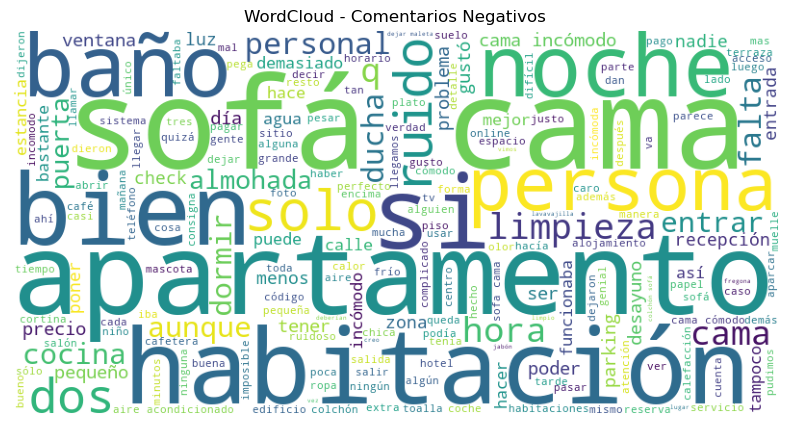

In [79]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(" ".join(tokens_neg_clean))

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud - Comentarios Negativos")
plt.show()

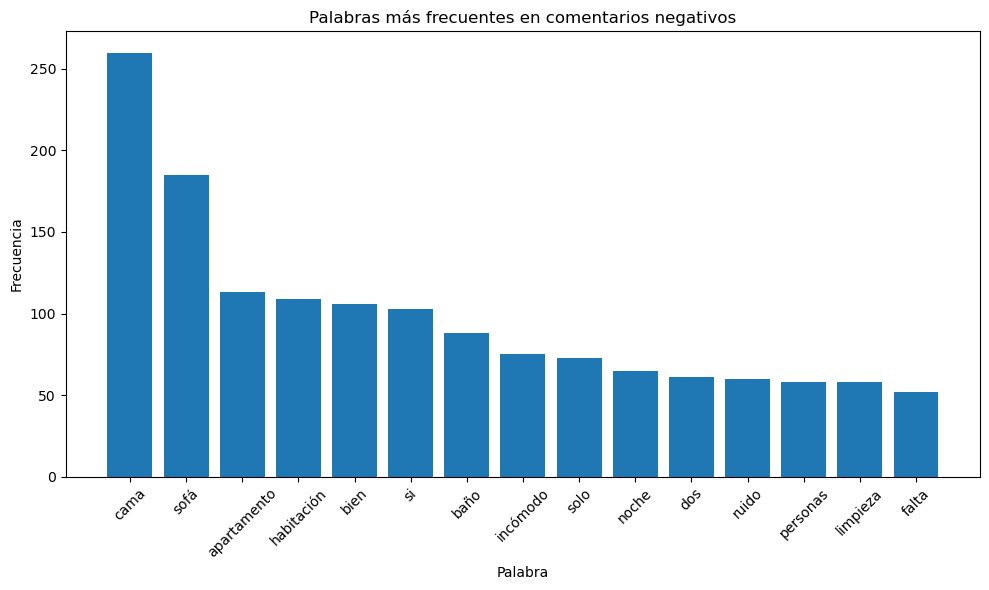

In [80]:
top_n = 15
top_words = freq_neg_df.head(top_n)

plt.figure(figsize=(10, 6))
plt.bar(top_words['Palabra'], top_words['Frecuencia'])
plt.xticks(rotation=45)
plt.title("Palabras más frecuentes en comentarios negativos")
plt.xlabel("Palabra")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()